# 10.1

In [1]:
import torch
from matplotlib import pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats

In [2]:
def show_heatmaps(matrices, xlabel, ylabel, titles=None, figsize=(2.5, 2.5), cmap='Reds'):
    set_matplotlib_formats("svg")
    num_rows, num_cols = matrices.shape[0], matrices.shape[1]
    fig, axes = plt.subplots(num_rows, num_cols, figsize=figsize, sharex=True, sharey=True, squeeze=False)

    for i, (row_axes, row_matrices) in enumerate(zip(axes, matrices)):
        for j, (ax, matrix) in enumerate(zip(row_axes, row_matrices)):
            pcm = ax.imshow(matrix.detach().numpy(), cmap=cmap)
            if i == num_rows - 1:
                ax.set_xlabel(xlabel)
            if j == 0:
                ax.set_ylabel(ylabel)
            if titles:
                ax.set_title(titles[j])
    fig.colorbar(pcm, ax=axes, shrink=0.6)

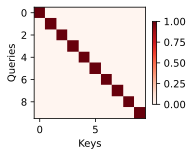

In [3]:
attention_weights = torch.eye(10).reshape((1, 1, 10, 10))
show_heatmaps(attention_weights, xlabel='Keys', ylabel='Queries')

# 10.2

In [4]:
import torch
from torch import nn


In [5]:
n_train = 50
x_train, _ = torch.sort(torch.rand(n_train) * 5)

def f(x):
    return 2 * torch.sin(x) + x ** 0.8

y_train = f(x_train) + torch.normal(0.0, 0.5, (n_train,))
x_test = torch.arange(0, 5, 0.1)
y_truth = f(x_test)
n_test = len(x_test)
n_test

50

In [6]:
def plot_kernel_reg(y_hat):
    plt.plot(x_train, y_train, 'o', alpha=0.5)
    plt.plot(x_test, y_truth, '-')
    plt.plot(x_test, y_hat, '--')
    plt.xlabel('x')
    plt.ylabel('y')

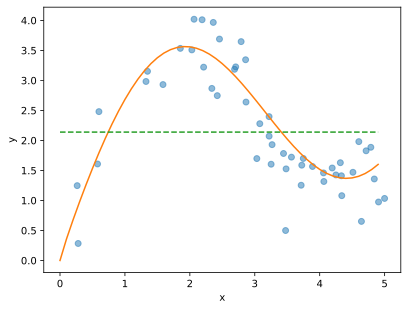

In [7]:
y_hat = torch.repeat_interleave(y_train.mean(), n_test)
plot_kernel_reg(y_hat)

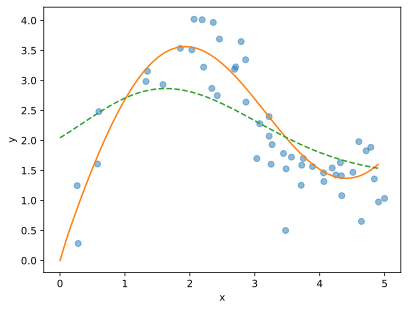

In [8]:
X_repeat = x_test.repeat_interleave(n_train).reshape(-1, n_train)
attention_weights = nn.functional.softmax(-(X_repeat - x_train) ** 2 / 2, dim=1)
y_hat = torch.matmul(attention_weights, y_train)
plot_kernel_reg(y_hat)

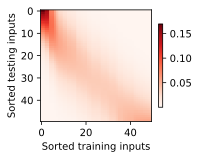

In [9]:
show_heatmaps(attention_weights.unsqueeze(0).unsqueeze(0), xlabel='Sorted training inputs', ylabel='Sorted testing inputs')

In [10]:
X = torch.ones((2, 1, 4))
Y = torch.ones((2, 4, 6))
torch.bmm(X, Y).shape

torch.Size([2, 1, 6])

In [11]:
weights = torch.ones((2, 10)) * 0.1
values = torch.arange(20.0).reshape((2, 10))
torch.bmm(weights.unsqueeze(1), values.unsqueeze(-1))

tensor([[[ 4.5000]],

        [[14.5000]]])

# 10.3

In [12]:
import math
import torch
from torch import nn

In [13]:
def sequence_mask(X, valid_lens, value=0):
    """遮蔽每行中超过有效长度的位置。"""
    valid_lens = valid_lens.to(X.device)

    positions = torch.arange(
        X.shape[1],
        device=X.device
    )[None, :]

    mask = positions < valid_lens[:, None]
    return X.masked_fill(~mask, value)

In [14]:
def masked_softmax(X, valid_lens):
    if valid_lens is None:
        return nn.functional.softmax(X, dim=-1)
    else:
        shape = X.shape

    if valid_lens.dim() == 1:
        # 每个 Query 都需要一份有效长度
        valid_lens = torch.repeat_interleave(
            valid_lens,
            repeats=shape[1]
        )
    else:
        valid_lens = valid_lens.reshape(-1)

    X = sequence_mask(X.reshape(-1, shape[-1]), valid_lens, value=-1e6)
    return nn.functional.softmax(X.reshape(shape), dim=-1)

In [15]:
class AdditiveAttention(nn.Module):
    def __init__(self, key_size, query_size, num_hiddens, dropout, **kwargs):
        super().__init__(**kwargs)
        self.W_k = nn.Linear(key_size, num_hiddens, bias=False)
        self.W_q = nn.Linear(query_size, num_hiddens, bias=False)
        self.w_v = nn.Linear(num_hiddens, 1, bias=False)
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens):
        queries, keys = self.W_q(queries), self.W_k(keys)
        features = queries.unsqueeze(2) + keys.unsqueeze(1)
        features = torch.tanh(features)
        scores = self.w_v(features).squeeze(-1)
        self.attention_weights = masked_softmax(scores, valid_lens)
        return torch.bmm(self.dropout(self.attention_weights), values)

In [16]:
class DotProductAttention(nn.Module):
    def __init__(self, dropout, **kwargs):
        super().__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens=None):
        d = queries.shape[-1]
        scores = torch.bmm(queries, keys.transpose(1, 2)) / math.sqrt(d)
        self.attention_weights = masked_softmax(scores, valid_lens)
        return torch.bmm(self.dropout(self.attention_weights), values)

# 10.5

In [17]:
import math
import torch
from torch import nn

In [18]:
class MultiHeadAttention(nn.Module):
    def __init__(self, key_size, query_size, value_size, num_hiddens,
                 num_heads, dropout, bias=False, **kwargs):
        super(MultiHeadAttention, self).__init__(**kwargs)
        self.num_heads = num_heads
        self.attention = DotProductAttention(dropout)
        self.W_q = nn.Linear(query_size, num_hiddens, bias=bias)
        self.W_k = nn.Linear(key_size, num_hiddens, bias=bias)
        self.W_v = nn.Linear(value_size, num_hiddens, bias=bias)
        self.W_o = nn.Linear(num_hiddens, num_hiddens, bias=bias)

    def forward(self, queries, keys, values, valid_lens):
        queries = transpose_qkv(self.W_q(queries), self.num_heads)
        keys = transpose_qkv(self.W_k(keys), self.num_heads)
        values = transpose_qkv(self.W_v(values), self.num_heads)

        if valid_lens is not None:
            valid_lens = torch.repeat_interleave(valid_lens,
                                                 repeats=self.num_heads,
                                                 dim=0)

        output = self.attention(queries, keys, values, valid_lens)

        output_concat = transpose_output(output, self.num_heads)
        return self.W_o(output_concat)

In [19]:
def transpose_qkv(X, num_heads):
    X = X.reshape(X.shape[0], X.shape[1], num_heads, -1)
    X = X.permute(0, 2, 1, 3)
    return X.reshape(-1, X.shape[2], X.shape[3])

def transpose_output(X, num_heads):
    X = X.reshape(-1, num_heads, X.shape[1], X.shape[2])
    X = X.permute(0, 2, 1, 3)
    return X.reshape(X.shape[0], X.shape[1], -1)

In [20]:
num_hiddens, num_heads = 100, 5
attention = MultiHeadAttention(num_hiddens, num_hiddens, num_hiddens, num_hiddens, num_heads, 0.5)
attention.eval()

MultiHeadAttention(
  (attention): DotProductAttention(
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (W_q): Linear(in_features=100, out_features=100, bias=False)
  (W_k): Linear(in_features=100, out_features=100, bias=False)
  (W_v): Linear(in_features=100, out_features=100, bias=False)
  (W_o): Linear(in_features=100, out_features=100, bias=False)
)

# 10.6

In [21]:
import math
import torch
from torch import nn

In [22]:
num_hiddens, num_heads = 100, 5
attention = MultiHeadAttention(num_hiddens, num_hiddens, num_hiddens, num_hiddens, num_heads, 0.5)
attention.eval()

MultiHeadAttention(
  (attention): DotProductAttention(
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (W_q): Linear(in_features=100, out_features=100, bias=False)
  (W_k): Linear(in_features=100, out_features=100, bias=False)
  (W_v): Linear(in_features=100, out_features=100, bias=False)
  (W_o): Linear(in_features=100, out_features=100, bias=False)
)

In [23]:
batch_size, num_queries, valid_lens = 2, 4, torch.tensor([3, 2])
X = torch.ones((batch_size, num_queries, num_hiddens))
attention(X, X, X, valid_lens).shape

torch.Size([2, 4, 100])

In [24]:
def plot(X, Y=None, xlabel=None, ylabel=None, legend=None,
         xlim=None, ylim=None, xscale='linear', yscale='linear',
         fmts=('-', 'm--', 'g-.', 'r:'), figsize=(3.5, 2.5), axes=None):
    """使用 Matplotlib 绘制一条或多条曲线，替代 d2l.plot。"""
    set_matplotlib_formats('svg')

    def as_series(data):
        """将一维数据视为一条曲线，二维数据按第一维拆成多条曲线。"""
        if isinstance(data, torch.Tensor):
            data = data.detach().cpu()
            if data.ndim == 1:
                return [data.numpy()]
            if data.ndim == 2:
                return [row.numpy() for row in data]
            raise ValueError('plot 只支持一维或二维张量')

        if isinstance(data, (list, tuple)):
            if not data:
                return []
            if isinstance(data[0], (list, tuple, torch.Tensor)):
                return [item.detach().cpu().numpy()
                        if isinstance(item, torch.Tensor) else item
                        for item in data]
            return [data]

        return [[data]]

    if Y is None:
        Y = X
        X = None

    ys = as_series(Y)
    if X is None:
        xs = [range(len(y)) for y in ys]
    else:
        xs = as_series(X)
        if len(xs) == 1:
            xs = xs * len(ys)

    if len(xs) != len(ys):
        raise ValueError('X 与 Y 的曲线数量不匹配')

    if axes is None:
        _, axes = plt.subplots(figsize=figsize)

    legend = [] if legend is None else legend
    for i, (x, y) in enumerate(zip(xs, ys)):
        label = legend[i] if i < len(legend) else None
        axes.plot(x, y, fmts[i % len(fmts)], label=label)

    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.set_xscale(xscale)
    axes.set_yscale(yscale)
    if xlim is not None:
        axes.set_xlim(xlim)
    if ylim is not None:
        axes.set_ylim(ylim)
    if legend:
        axes.legend()
    axes.grid(True)
    return axes

In [25]:
#@save
class PositionalEncoding(nn.Module):
    """位置编码"""
    def __init__(self, num_hiddens, dropout, max_len=1000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(dropout)
        # 创建一个足够长的P
        self.P = torch.zeros((1, max_len, num_hiddens))
        X = torch.arange(max_len, dtype=torch.float32).reshape(
            -1, 1) / torch.pow(10000, torch.arange(
            0, num_hiddens, 2, dtype=torch.float32) / num_hiddens)
        self.P[:, :, 0::2] = torch.sin(X)
        self.P[:, :, 1::2] = torch.cos(X)

    def forward(self, X):
        X = X + self.P[:, :X.shape[1], :].to(X.device)
        return self.dropout(X)

<Axes: xlabel='Row (position)'>

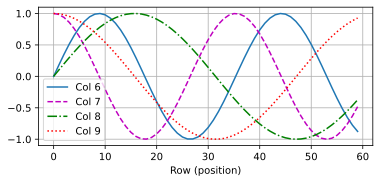

In [26]:
encoding_dim, num_steps = 32, 60
pos_encoding = PositionalEncoding(encoding_dim, 0)
pos_encoding.eval()
X = pos_encoding(torch.zeros((1, num_steps, encoding_dim)))
P = pos_encoding.P[:, :X.shape[1], :]
plot(torch.arange(num_steps), P[0, :, 6:10].T, xlabel='Row (position)',
         figsize=(6, 2.5), legend=["Col %d" % d for d in torch.arange(6, 10)])

In [27]:
for i in range(8):
    print(f'{i}的二进制是：{i:>03b}')

0的二进制是：000
1的二进制是：001
2的二进制是：010
3的二进制是：011
4的二进制是：100
5的二进制是：101
6的二进制是：110
7的二进制是：111


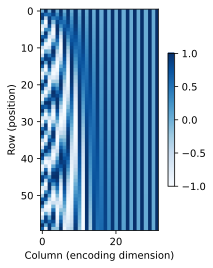

In [28]:
P = P[0, :, :].unsqueeze(0).unsqueeze(0)
show_heatmaps(P, xlabel='Column (encoding dimension)',
                  ylabel='Row (position)', figsize=(3.5, 4), cmap='Blues')

In [29]:
import pandas as pd

In [30]:
class PositionWiseFFN(nn.Module):
    """基于位置的前馈网络"""
    def __init__(self, ffn_num_input, ffn_num_hiddens, ffn_num_outputs,
                 **kwargs):
        super(PositionWiseFFN, self).__init__(**kwargs)
        self.dense1 = nn.Linear(ffn_num_input, ffn_num_hiddens)
        self.relu = nn.ReLU()
        self.dense2 = nn.Linear(ffn_num_hiddens, ffn_num_outputs)

    def forward(self, X):
        return self.dense2(self.relu(self.dense1(X)))

In [31]:
ffn = PositionWiseFFN(4, 4, 8)
ffn.eval()
ffn(torch.ones((2, 3, 4)))[0]

tensor([[-0.7628,  0.0176, -0.1145,  0.0690, -0.1062,  0.4018, -0.6354,  0.1037],
        [-0.7628,  0.0176, -0.1145,  0.0690, -0.1062,  0.4018, -0.6354,  0.1037],
        [-0.7628,  0.0176, -0.1145,  0.0690, -0.1062,  0.4018, -0.6354,  0.1037]],
       grad_fn=<SelectBackward0>)

In [33]:
ln = nn.LayerNorm(2)
bn = nn.BatchNorm1d(2)
X = torch.tensor([[1, 2], [2, 3]], dtype=torch.float32)

print('LayerNorm:', ln(X), '\nbatch norm:', bn(X))

LayerNorm: tensor([[-1.0000,  1.0000],
        [-1.0000,  1.0000]], grad_fn=<NativeLayerNormBackward0>) 
batch norm: tensor([[-1.0000, -1.0000],
        [ 1.0000,  1.0000]], grad_fn=<NativeBatchNormBackward0>)


In [34]:
class AddNorm(nn.Module):
    """残差连接后进行层规范化"""
    def __init__(self, normalized_shape, dropout, **kwargs):
        super(AddNorm, self).__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)
        self.ln = nn.LayerNorm(normalized_shape)

    def forward(self, X, Y):
        return self.ln(self.dropout(Y) + X)

In [35]:
add_norm = AddNorm([3, 4], 0.5)
add_norm.eval()
add_norm(torch.ones((2, 3, 4)), torch.ones((2, 3, 4)))[0]

tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]], grad_fn=<SelectBackward0>)

In [36]:
class EncoderBlock(nn.Module):
    """Transformer编码器块"""
    def __init__(self, key_size, query_size, value_size, num_hiddens,
                 norm_shape, ffn_num_input, ffn_num_hiddens, num_heads,
                 dropout, use_bias=False, **kwargs):
        super(EncoderBlock, self).__init__(**kwargs)
        self.attention = MultiHeadAttention(key_size, query_size, value_size,
                                            num_hiddens, num_heads, dropout,
                                            use_bias)
        self.addnorm1 = AddNorm(norm_shape, dropout)
        self.ffn = PositionWiseFFN(ffn_num_input, ffn_num_hiddens,
                                   num_hiddens)
        self.addnorm2 = AddNorm(norm_shape, dropout)

    def forward(self, X, valid_lens):
        Y = self.addnorm1(X, self.attention(X, X, X, valid_lens))
        return self.addnorm2(Y, self.ffn(Y))

In [37]:
class TransformerEncoder(nn.Module):
    """Transformer编码器"""
    def __init__(self, vocab_size, key_size, query_size, value_size,
                 num_hiddens, norm_shape, ffn_num_input, ffn_num_hiddens,
                 num_heads, num_layers, dropout, use_bias=False, **kwargs):
        super(TransformerEncoder, self).__init__(**kwargs)
        self.num_hiddens = num_hiddens
        self.embedding = nn.Embedding(vocab_size, num_hiddens)
        self.pos_encoding = PositionalEncoding(num_hiddens, dropout)
        self.blks = nn.Sequential()
        for i in range(num_layers):
            self.blks.add_module("block" + str(i),
                                 EncoderBlock(key_size, query_size,
                                              value_size, num_hiddens,
                                              norm_shape, ffn_num_input,
                                              ffn_num_hiddens, num_heads,
                                              dropout, use_bias))

    def forward(self, X, valid_lens, *args):
        # 在进入编码器之前，添加位置编码
        X = self.pos_encoding(self.embedding(X) * math.sqrt(self.num_hiddens))
        self.attention_weights = [None] * len(self.blks)
        for i, blk in enumerate(self.blks):
            X = blk(X, valid_lens)
            self.attention_weights[i] = blk.attention.attention.attention_weights
        return X

In [38]:
encoder = TransformerEncoder(200, 24, 24, 24, 24, [100, 24], 24, 48, 8, 2, 0.5)
encoder.eval()
encoder(torch.ones((2, 100), dtype=torch.long), valid_lens).shape

torch.Size([2, 100, 24])

In [39]:
class DecoderBlock(nn.Module):
    """Transformer解码器块"""
    def __init__(self, key_size, query_size, value_size, num_hiddens,
                 norm_shape, ffn_num_input, ffn_num_hiddens, num_heads,
                 dropout, i, **kwargs):
        super(DecoderBlock, self).__init__(**kwargs)
        self.i = i
        self.attention1 = MultiHeadAttention(key_size, query_size,
                                             value_size, num_hiddens,
                                             num_heads, dropout)
        self.addnorm1 = AddNorm(norm_shape, dropout)
        self.attention2 = MultiHeadAttention(key_size, query_size,
                                             value_size, num_hiddens,
                                             num_heads, dropout)
        self.addnorm2 = AddNorm(norm_shape, dropout)
        self.ffn = PositionWiseFFN(ffn_num_input, ffn_num_hiddens,
                                   num_hiddens)
        self.addnorm3 = AddNorm(norm_shape, dropout)

    def forward(self, X, state):
        enc_outputs, enc_valid_lens = state[0], state[1]
        # 训练阶段，输出序列的所有词元都在同一时间处理
        # 因此state[2][self.i]初始化为None
        if state[2][self.i] is None:
            key_values = X
        # 预测阶段，输出序列是通过词元一个接一个解码的
        else:
            key_values = torch.cat((state[2][self.i], X), axis=1)
        state[2][self.i] = key_values
        if self.training:
            batch_size, num_steps, _ = X.shape
            dec_valid_lens = torch.arange(1, num_steps + 1,
                                          device=X.device).repeat(batch_size,
                                                                  1)
        else:
            dec_valid_lens = None

        X2 = self.attention1(X, key_values, key_values, dec_valid_lens)
        Y = self.addnorm1(X, X2)
        Y2 = self.attention2(Y, enc_outputs, enc_outputs, enc_valid_lens)
        Z = self.addnorm2(Y, Y2)
        return self.addnorm3(Z, self.ffn(Z)), state

In [41]:
class AttentionDecoder(nn.Module):
    """带有注意力机制的解码器基本接口"""
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def init_state(self, enc_outputs, enc_valid_lens, *args):
        """根据编码器输出初始化解码器状态。"""
        raise NotImplementedError

    def forward(self, X, state):
        """接收当前输入和状态，返回输出与更新后的状态。"""
        raise NotImplementedError

    @property
    def attention_weights(self):
        """返回注意力权重，供可视化或分析使用。"""
        raise NotImplementedError

In [42]:
class TransformerDecoder(AttentionDecoder):
    def __init__(self, vocab_size, key_size, query_size, value_size,
                 num_hiddens, norm_shape, ffn_num_input, ffn_num_hiddens,
                 num_heads, num_layers, dropout, **kwargs):
        super(TransformerDecoder, self).__init__(**kwargs)
        self.num_hiddens = num_hiddens
        self.layers = num_layers
        self.embedding = nn.Embedding(vocab_size, num_hiddens)
        self.pos_encoding = PositionalEncoding(num_hiddens, dropout)
        self.blks = nn.Sequential()
        for i in range(num_layers):
            self.blks.add_module("block" + str(i),
                                 DecoderBlock(key_size, query_size,
                                              value_size, num_hiddens,
                                              norm_shape, ffn_num_input,
                                              ffn_num_hiddens, num_heads,
                                              dropout, i))
        self.dense = nn.Linear(num_hiddens, vocab_size)

    def init_state(self, enc_outputs, enc_valid_lens, *args):
        return [enc_outputs, enc_valid_lens, [None] * self.layers]

    def forward(self, X, state):
        X = self.pos_encoding(self.embedding(X) * math.sqrt(self.num_hiddens))
        self._attention_weights = [[None] * len(self.blks) for _ in range(2)]
        for i, blk in enumerate(self.blks):
            X, state = blk(X, state)
            self._attention_weights[0][i] = blk.attention1.attention.attention_weights
            self._attention_weights[1][i] = blk.attention2.attention.attention_weights
        return self.dense(X), state

    @property
    def attention_weights(self):
        return self._attention_weights

In [44]:
import collections
import time
import urllib.request
import zipfile
from pathlib import Path
from torch.utils.data import DataLoader, TensorDataset


def try_gpu(i=0):
    """存在 GPU 时返回 GPU，否则返回 CPU。"""
    return torch.device(f'cuda:{i}' if torch.cuda.device_count() > i else 'cpu')


class Vocab:
    """将词元映射为整数索引。"""
    def __init__(self, tokens=None, min_freq=0, reserved_tokens=None):
        tokens = [] if tokens is None else tokens
        reserved_tokens = [] if reserved_tokens is None else reserved_tokens
        counter = collections.Counter(token for line in tokens for token in line)
        self.token_freqs = sorted(counter.items(), key=lambda x: x[1], reverse=True)
        self.idx_to_token = ['<unk>'] + reserved_tokens
        self.token_to_idx = {token: idx for idx, token in enumerate(self.idx_to_token)}
        for token, freq in self.token_freqs:
            if freq < min_freq:
                break
            if token not in self.token_to_idx:
                self.idx_to_token.append(token)
                self.token_to_idx[token] = len(self.idx_to_token) - 1

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, tokens):
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk)
        return [self[token] for token in tokens]

    def to_tokens(self, indices):
        if not isinstance(indices, (list, tuple)):
            return self.idx_to_token[indices]
        return [self.idx_to_token[index] for index in indices]

    @property
    def unk(self):
        return 0


class EncoderDecoder(nn.Module):
    """组合编码器和解码器。"""
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, enc_X, dec_X, *args):
        enc_outputs = self.encoder(enc_X, *args)
        dec_state = self.decoder.init_state(enc_outputs, *args)
        return self.decoder(dec_X, dec_state)


class MaskedSoftmaxCELoss(nn.CrossEntropyLoss):
    """忽略填充词元的交叉熵损失。"""
    def forward(self, pred, label, valid_len):
        weights = torch.ones_like(label, dtype=torch.float32)
        weights = sequence_mask(weights, valid_len)
        self.reduction = 'none'
        unweighted_loss = super().forward(pred.permute(0, 2, 1), label)
        return (unweighted_loss * weights).mean(dim=1)


def _nmt_data_dir():
    cwd = Path.cwd()
    if (cwd / 'd2l' / 'attention.ipynb').exists():
        return cwd / 'data'
    if cwd.name == 'd2l':
        return cwd.parent / 'data'
    return cwd / 'data'


def _download_nmt():
    data_dir = _nmt_data_dir()
    data_dir.mkdir(parents=True, exist_ok=True)
    archive = data_dir / 'fra-eng.zip'
    data_file = data_dir / 'fra-eng' / 'fra.txt'
    if not archive.exists():
        url = 'https://d2l-data.s3-accelerate.amazonaws.com/fra-eng.zip'
        print('正在下载英法翻译数据集……')
        urllib.request.urlretrieve(url, archive)
    if not data_file.exists():
        with zipfile.ZipFile(archive, 'r') as zf:
            zf.extractall(data_dir)
    return data_file


def _preprocess_nmt(text):
    text = text.replace('\u202f', ' ').replace('\xa0', ' ').lower()
    return ''.join((' ' + char) if char in ',.!?' and i > 0 and text[i - 1] != ' ' else char
                   for i, char in enumerate(text))


def _tokenize_nmt(text, num_examples=None):
    source, target = [], []
    for i, line in enumerate(text.splitlines()):
        if num_examples is not None and i >= num_examples:
            break
        parts = line.split('\t')
        if len(parts) >= 2:
            source.append(parts[0].split(' '))
            target.append(parts[1].split(' '))
    return source, target


def _truncate_pad(line, num_steps, padding_token):
    if len(line) > num_steps:
        return line[:num_steps]
    return line + [padding_token] * (num_steps - len(line))


def _build_array_nmt(lines, vocab, num_steps):
    lines = [vocab[line] + [vocab['<eos>']] for line in lines]
    array = torch.tensor([_truncate_pad(line, num_steps, vocab['<pad>'])
                          for line in lines])
    valid_len = (array != vocab['<pad>']).sum(dim=1)
    return array, valid_len


def load_data_nmt(batch_size, num_steps, num_examples=600):
    """加载英法翻译数据；首次调用时下载数据集。"""
    text = _download_nmt().read_text(encoding='utf-8')
    source, target = _tokenize_nmt(_preprocess_nmt(text), num_examples)
    reserved = ['<pad>', '<bos>', '<eos>']
    src_vocab = Vocab(source, min_freq=2, reserved_tokens=reserved)
    tgt_vocab = Vocab(target, min_freq=2, reserved_tokens=reserved)
    src_array, src_valid_len = _build_array_nmt(source, src_vocab, num_steps)
    tgt_array, tgt_valid_len = _build_array_nmt(target, tgt_vocab, num_steps)
    dataset = TensorDataset(src_array, src_valid_len, tgt_array, tgt_valid_len)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True), src_vocab, tgt_vocab


def _grad_clipping(net, theta):
    params = [p for p in net.parameters() if p.requires_grad and p.grad is not None]
    norm = torch.sqrt(sum(torch.sum(p.grad ** 2) for p in params))
    if norm > theta:
        for param in params:
            param.grad[:] *= theta / norm


def train_seq2seq(net, data_iter, lr, num_epochs, tgt_vocab, device):
    """使用教师强制训练序列到序列模型。"""
    def xavier_init_weights(module):
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)

    net.apply(xavier_init_weights)
    net.to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)
    loss = MaskedSoftmaxCELoss()
    net.train()
    start = time.time()
    for epoch in range(num_epochs):
        loss_sum, token_sum = 0.0, 0
        for X, X_valid_len, Y, Y_valid_len in data_iter:
            X, X_valid_len = X.to(device), X_valid_len.to(device)
            Y, Y_valid_len = Y.to(device), Y_valid_len.to(device)
            bos = torch.full((Y.shape[0], 1), tgt_vocab['<bos>'],
                             dtype=Y.dtype, device=device)
            dec_input = torch.cat((bos, Y[:, :-1]), dim=1)
            optimizer.zero_grad()
            Y_hat, _ = net(X, dec_input, X_valid_len)
            batch_loss = loss(Y_hat, Y, Y_valid_len)
            batch_loss.sum().backward()
            _grad_clipping(net, 1.0)
            optimizer.step()
            loss_sum += batch_loss.sum().item()
            token_sum += Y_valid_len.sum().item()
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f'epoch {epoch + 1:3d}, loss {loss_sum / token_sum:.4f}')
    print(f'训练完成，用时 {time.time() - start:.1f} 秒，设备 {device}')

In [45]:
num_hiddens, num_layers, dropout, batch_size, num_steps = 32, 2, 0.1, 64, 10
lr, num_epochs, device = 0.005, 200, try_gpu()
ffn_num_hiddens, num_heads = 64, 4

train_iter, src_vocab, tgt_vocab = load_data_nmt(batch_size, num_steps)

encoder = TransformerEncoder(
    len(src_vocab), num_hiddens, num_hiddens, num_hiddens, num_hiddens,
    [num_hiddens], num_hiddens, ffn_num_hiddens, num_heads, num_layers,
    dropout)
decoder = TransformerDecoder(
    len(tgt_vocab), num_hiddens, num_hiddens, num_hiddens, num_hiddens,
    [num_hiddens], num_hiddens, ffn_num_hiddens, num_heads, num_layers,
    dropout)
net = EncoderDecoder(encoder, decoder)
train_seq2seq(net, train_iter, lr, num_epochs, tgt_vocab, device)

正在下载英法翻译数据集……
epoch   1, loss 0.4418
epoch  10, loss 0.1833
epoch  20, loss 0.1299
epoch  30, loss 0.0987
epoch  40, loss 0.0790
epoch  50, loss 0.0659
epoch  60, loss 0.0570
epoch  70, loss 0.0551
epoch  80, loss 0.0470
epoch  90, loss 0.0462
epoch 100, loss 0.0424
epoch 110, loss 0.0388
epoch 120, loss 0.0367
epoch 130, loss 0.0357
epoch 140, loss 0.0366
epoch 150, loss 0.0343
epoch 160, loss 0.0336
epoch 170, loss 0.0336
epoch 180, loss 0.0303
epoch 190, loss 0.0309
epoch 200, loss 0.0309
训练完成，用时 18.3 秒，设备 cuda:0
